In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import itertools as it
import scipy.stats.qmc as ssq
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from skopt import BayesSearchCV
from skopt.space.space import Real, Integer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

np.set_printoptions(threshold=100_000)
X = pd.read_csv(r"C:\Users\dwigh\OneDrive\Desktop\Emissions Uncertainty on Antarctic Instability\ensemble_output\results\peaking\parameters.csv")

Y = pd.read_csv(r"C:\Users\dwigh\OneDrive\Desktop\Emissions Uncertainty on Antarctic Instability\ensemble_output\results\peaking\gmslr.csv")
Y = Y.mean(axis=1).rename('output')
obj = X.join(Y, how='left')
# obj.sort_values(by='t_peak',ascending=True, inplace=True)

In [15]:
val = train_test_split(obj.iloc[:,:-1],obj.iloc[:,-1], train_size=0.8, random_state=0)
RF =RandomForestRegressor(n_estimators=300,n_jobs=20, random_state=0)
RF.fit(val[0],val[2])

RandomForestRegressor(n_estimators=300, n_jobs=20, random_state=0)

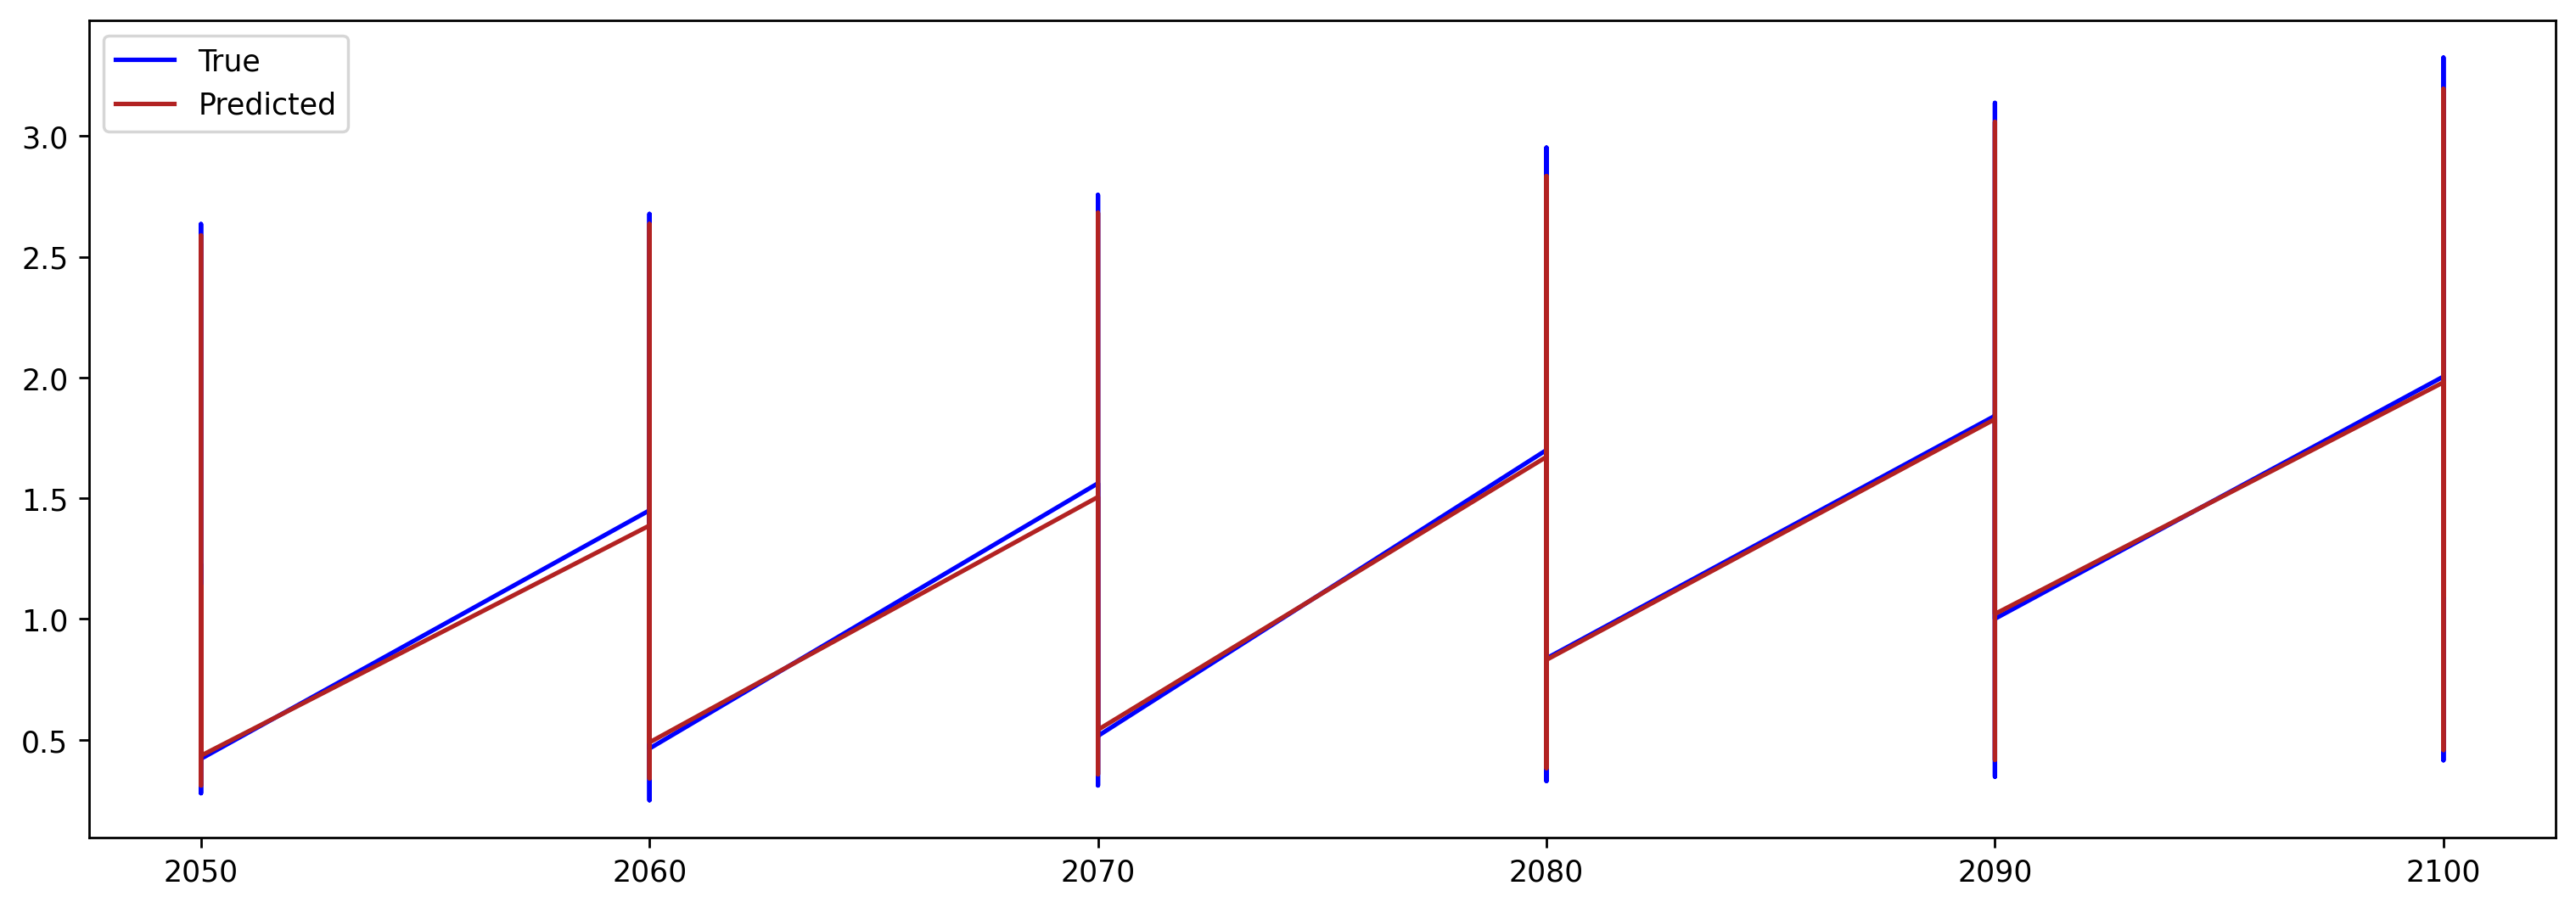

In [16]:
fig, ax = plt.subplots(1,1, figsize=(15,5), dpi=250)
ax.plot(obj.t_peak, obj.output, color='blue', label='True')
ax.plot(obj.t_peak, RF.predict(obj.iloc[:,:-1]), color='firebrick', label='Predicted')
ax.legend()
plt.show()

In [4]:
rng = np.random.default_rng(seed=0)
def bootstrapp(y_true,y_pred,n_boots):
    rows = len(y_true)
    error = (y_true - y_pred).to_numpy()
    S_CI = np.zeros((n_boots,))
    for i in range(n_boots):
        indx = rng.choice(rows, size=rows, replace=True)
        S_CI[i] = np.mean(np.square(error[indx]))
    return S_CI

In [31]:
def mod_pvi1(data: pd.DataFrame, y_true: np.ndarray[float], f: callable,*, n_boots: int, alpha: float, column_set: dict) -> tuple[pd.DataFrame]:
    rows, columns = data.shape
    npv_columns = column_set
    V_y = np.var(y_true, ddof=1)
    u = dict()
    CI = dict()
    rolled_data = pd.DataFrame(np.roll(data.copy(),1, axis=0), columns=data.columns)
    # rolled_data = np.roll(data.copy(), rows//2, axis=0)
    for col in npv_columns:
        d = rolled_data.copy()
        d[col] = data[col].to_numpy()
        y_pred = f(d)
        u[col] = 1-np.mean(np.square(y_true - y_pred))/(2*V_y)
        S_CI = 1 - bootstrapp(y_true,y_pred, n_boots)/(2*V_y)
        p0,p1 = np.quantile(S_CI, [alpha,1-alpha])
        CI[col] = [p0,p1,p1-p0]
    CI = pd.DataFrame(CI.values(), index = CI.keys(), columns=['5th','95th','Quantile Difference'])
    CI.index.name = 'Interactions'
    CI.columns.name = 'Confidence Interval Difference'
    SI = pd.DataFrame(u.values(), index=u.keys(), columns=['$P_{i}$'])
    return u,CI

In [34]:
def mod_pvi_t(data: np.ndarray[float], y_true: np.ndarray[float], f: callable,*,n_boots: int, alpha: float, column_set: list[str]) -> np.ndarray[float]:
    '''
    ===Total-Order Permutation Variable Importances===

        data: your training dataset
        y_pred: your model output (specifically the prediction of your 'data' arg)
        f: in this case, simply RF.predict
    '''
    rows, columns = data.shape
    npv_columns = column_set
    u = dict()
    V_y = np.var(y_true,ddof=1 )
    CI = dict()
    for col in npv_columns:
        d = data.copy()
        d[col] = np.roll(data[col],1, axis=0)
        y_pred = f(d)
        u[col] = np.mean(np.square(y_true - y_pred))/(2*V_y)
        S_CI = bootstrapp(y_true,y_pred, n_boots)/(2*V_y)
        p0,p1 = np.quantile(S_CI, [alpha,1-alpha])
        CI[col] = [p0,p1,p1-p0]
    CI = pd.DataFrame(CI.values(), index = CI.keys(), columns=['5th','95th','Quantile Difference'])
    CI.index.name = 'Interactions'
    CI.columns.name = 'Confidence Interval Difference'
    S_t = pd.DataFrame(u.values(), index=u.keys(), columns=[r'$P_{\tau}$'])
    return u, CI

In [35]:
def mod_pvi2(data: pd.DataFrame, y_true: np.ndarray[float], f: callable,*,PI:dict, n_boots: int, alpha: float, column_set: dict) -> tuple[pd.DataFrame]:
    rows, columns = data.shape
    npv_columns = column_set
    V_y = np.var(y_true, ddof=1)
    u = dict()
    CI = dict()
    rolled_data = pd.DataFrame(np.roll(data.copy(),1, axis=0), columns=data.columns)
    # rolled_data = np.roll(data.copy(), rows//2, axis=0)
    for col1, col2 in it.combinations(npv_columns,r=2):
        col = col1+','+col2
        d = rolled_data.copy()
        d[[col1,col2]] = data[[col1,col2]].to_numpy()
        y_pred = f(d)
        u[col] = 1-np.mean(np.square(y_true - y_pred))/(2*V_y) - PI[col1] - PI[col2]
        print(f'Columns:{col}\t{u[col]}')
        S_CI = 1 - bootstrapp(y_true,y_pred, n_boots)/(2*V_y) - PI[col1] - PI[col2]
        p0,p1 = np.quantile(S_CI, [alpha,1-alpha])
        CI[(col1, col2)] = [p0,p1,p1-p0]
    CI = pd.DataFrame(CI.values(), index = CI.keys(), columns=['5th','95th','Quantile Difference'])
    CI.index.name = 'Interactions'
    CI.columns.name = 'Confidence Interval Difference'
    SI = pd.DataFrame(u.values(), index=u.keys(), columns=['$P_{i}$'])
    return u,CI

In [43]:
PI, CI = mod_pvi1(val[1], val[3], RF.predict, n_boots=1000, alpha=0.05, column_set=val[0].columns)

In [44]:
PI

{'gamma_g': np.float64(0.1305187724472735),
 't_peak': np.float64(0.360932052620878),
 'gamma_d': np.float64(0.19318157233262012),
 'sd_temp': np.float64(0.08509950285772117),
 'sd_ocean_heat': np.float64(0.0851603005276077),
 'sd_glaciers': np.float64(0.08499384841346724),
 'sd_greenland': np.float64(0.08553702397266982),
 'sd_antarctic': np.float64(0.08544630687187293),
 'sd_gmsl': np.float64(0.08536747671500977),
 'rho_temperature': np.float64(0.08516544288079231),
 'rho_ocean_heat': np.float64(0.08493961234940006),
 'rho_glaciers': np.float64(0.08503186622460723),
 'rho_greenland': np.float64(0.08721990234292343),
 'rho_antarctic': np.float64(0.08555015254539611),
 'rho_gmsl': np.float64(0.08564291840858351),
 'CO2_0': np.float64(0.08529873253580778),
 'N2O_0': np.float64(0.08524929667820003),
 'temperature_0': np.float64(0.0883422901117642),
 'ocean_heat_0': np.float64(0.08635584789192197),
 'thermal_s0': np.float64(0.08523760489338239),
 'greenland_v0': np.float64(0.0852509597845

In [45]:
PT, CT = mod_pvi_t(val[1], val[3], RF.predict, n_boots=1000, alpha=0.05, column_set=val[0].columns)

In [46]:
PT

{'gamma_g': np.float64(0.09892812191719812),
 't_peak': np.float64(0.41030938529395866),
 'gamma_d': np.float64(0.16672861132532746),
 'sd_temp': np.float64(0.03212867189433681),
 'sd_ocean_heat': np.float64(0.03217902866542962),
 'sd_glaciers': np.float64(0.032104419332959135),
 'sd_greenland': np.float64(0.0322412766141281),
 'sd_antarctic': np.float64(0.032374479089217666),
 'sd_gmsl': np.float64(0.032244650311911996),
 'rho_temperature': np.float64(0.03214823307230008),
 'rho_ocean_heat': np.float64(0.03210145052009183),
 'rho_glaciers': np.float64(0.03210490008112601),
 'rho_greenland': np.float64(0.032564560122528625),
 'rho_antarctic': np.float64(0.032203837081667505),
 'rho_gmsl': np.float64(0.03239415552295412),
 'CO2_0': np.float64(0.03218818604130889),
 'N2O_0': np.float64(0.03212125159456074),
 'temperature_0': np.float64(0.032594931767082586),
 'ocean_heat_0': np.float64(0.03233622856589534),
 'thermal_s0': np.float64(0.03212194978828267),
 'greenland_v0': np.float64(0.032

In [47]:
PIK, CIK = mod_pvi2(val[1], val[3], RF.predict,PI=PI, n_boots=1000, alpha=0.05, column_set=val[0].columns)

Columns:gamma_g,t_peak	-0.04804752434444204
Columns:gamma_g,gamma_d	-0.09002460382497857
Columns:gamma_g,sd_temp	-0.08471293065519303
Columns:gamma_g,sd_ocean_heat	-0.08472689090304364
Columns:gamma_g,sd_glaciers	-0.08467153752322776
Columns:gamma_g,sd_greenland	-0.08490444498461336
Columns:gamma_g,sd_antarctic	-0.08483941451418708
Columns:gamma_g,sd_gmsl	-0.08483451990884372
Columns:gamma_g,rho_temperature	-0.08486139511037938
Columns:gamma_g,rho_ocean_heat	-0.08466305102335936
Columns:gamma_g,rho_glaciers	-0.08479917624990985
Columns:gamma_g,rho_greenland	-0.08510425321459936
Columns:gamma_g,rho_antarctic	-0.08491331229041155
Columns:gamma_g,rho_gmsl	-0.08496813028411809
Columns:gamma_g,CO2_0	-0.08484100177870213
Columns:gamma_g,N2O_0	-0.08474516845898739
Columns:gamma_g,temperature_0	-0.08480332935206569
Columns:gamma_g,ocean_heat_0	-0.08471076962263546
Columns:gamma_g,thermal_s0	-0.08475740202860893
Columns:gamma_g,greenland_v0	-0.08476773642556412
Columns:gamma_g,glaciers_v0	-0.08

In [48]:
arr = np.array(list(PIK.values()))
ind = (arr>0).nonzero()

In [49]:
ind

(array([], dtype=int64),)